### chr10 core-cenhap analysis
In this notebook, normalized counts of cenhap-specific k-mers are used to train a Random Forest classifier, with each cenhap treated as an independent target in a multi-label classification setting.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score

# Train model

In [3]:
# Set chromosome and names of clade-specific kmers
chrom = 'chr11'
norm_kmer = 'cen11_hor'

In [5]:
# Load and normalize input k-mer count data in 1000 Genomes
raw_counts = pd.read_csv('inputs/modern_counts.tsv', sep='\t').set_index('id')
norm_counts = raw_counts.div(raw_counts[norm_kmer], axis=0)

# select kmers for prediction
selected_kmers = ['ch1-1', 'ch1-2', 'ch2-1', 'ch2-2', 'ch3,6-1', 'ch3,6-2', 'ch4-1', 'ch4-2', 'ch5-1', 'ch5-2', 'ch7-1', 'ch7-2', 'ch9-1', 'ch9-2', 'ch10-1', 'ch10-2', 'ch11-1', 'ch11-2', 'ch12-1', 'ch12-2']
norm_counts = norm_counts.loc[:, selected_kmers]

# Load haplotype labels
metadata = pd.read_csv('inputs/metadata.tsv', sep='\t').set_index('id')
# merge undistingushable cenhaps
metadata['mat_cenhap'] = metadata['mat_cenhap'].astype('Int64').astype('str')
metadata['pat_cenhap'] = metadata['pat_cenhap'].astype('Int64').astype('str')
merger_dict = {'3': '3/6', '6': '3/6'}
metadata['mat_cenhap'] = metadata['mat_cenhap'].apply(lambda x: merger_dict[x] if x in merger_dict else x)
metadata['pat_cenhap'] = metadata['pat_cenhap'].apply(lambda x: merger_dict[x] if x in merger_dict else x)    
# get cenhap df
flank_cenhaps = metadata[['mat_cenhap', 'pat_cenhap']].dropna()
number_of_cenhaps = len(set(np.concatenate((flank_cenhaps['mat_cenhap'], flank_cenhaps['pat_cenhap']))))

# Keep only samples with haplotype assignments
norm_counts = norm_counts.loc[flank_cenhaps.index]

In [8]:
# Encode haplotype targets and split the dataset
hap_classes = list(set(list(metadata['mat_cenhap'].unique()) + list(metadata['pat_cenhap'].unique())))
hap_classes.remove(np.nan)
mlb = MultiLabelBinarizer(classes=hap_classes)
Y = mlb.fit_transform(flank_cenhaps.values)
X = norm_counts.values

# train/test split
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, Y, norm_counts.index, test_size=0.2, random_state=42
)

# add train/test status of sample to metadata
metadata.loc[idx_train, 'subsample'] = 'train'
metadata.loc[idx_test, 'subsample'] = 'test'

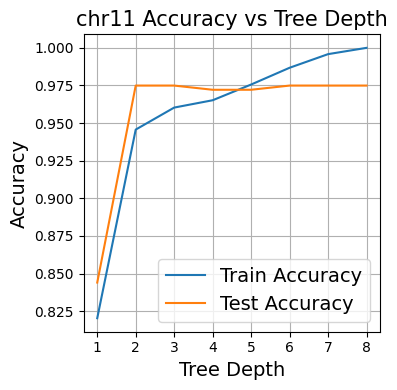

In [13]:
# Plot accuracy vs tree depth to detect overfitting
depths = list(range(1, 9))
train_acc = []
test_acc = []

for depth in depths:
    clf = MultiOutputClassifier(RandomForestClassifier(max_depth=depth, n_estimators=100, random_state=42))
    clf.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, clf.predict(X_train)))
    test_acc.append(accuracy_score(y_test, clf.predict(X_test)))

plt.figure(figsize=(4, 4))
plt.plot(depths, train_acc, label='Train Accuracy')
plt.plot(depths, test_acc, label='Test Accuracy')
plt.xlabel('Tree Depth', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.title(f'{chrom} Accuracy vs Tree Depth', fontsize=15)
plt.xticks(depths)
plt.grid(True, which='both', axis='x')
plt.grid(True, axis='y')
plt.legend(fontsize=14)
plt.tight_layout()
plt.savefig('outputs/accuracy-depth.png', bbox_inches='tight', dpi=200)
plt.show()

Let's pick depth 5 for not to get too overfit

In [15]:
# Train final model with chosen depth and evaluate accuracy
model = MultiOutputClassifier(RandomForestClassifier(max_depth=5, n_estimators=100, random_state=42))
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Train accuracy: {train_acc:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

Train accuracy: 0.9756
Test accuracy: 0.9721


In [16]:
# Compute and display feature importance table
importances = np.mean([est.feature_importances_ for est in model.estimators_], axis=0)
feature_importance = pd.DataFrame({
    'kmer': norm_counts.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)
feature_importance

,kmer,importance
15,ch10-2,0.074463
18,ch12-1,0.068623
19,ch12-2,0.065928
17,ch11-2,0.061080
14,ch10-1,0.058734
10,ch7-1,0.057990
5,"ch3,6-2",0.057641
12,ch9-1,0.053785
11,ch7-2,0.051818
0,ch1-1,0.048467


# Predict core-cenhaps

### Prediction function

In [17]:
# Prediction function
def predict_core_cenhap(path_to_counts_file):

    # Load counts
    raw_counts = pd.read_csv(path_to_counts_file, sep='\t').set_index('id')

    # Normalize counts by h1_kemr + h2_kmer
    norm_counts = raw_counts.div(raw_counts[norm_kmer], axis=0)

    # select kmers for prediction
    norm_counts = norm_counts.loc[:, selected_kmers]
    
    # Predict using the trained model
    X_new = norm_counts[norm_counts.columns].values
    y_pred = model.predict(X_new)
    
    # Convert to string labels
    core_cenhaps = pd.DataFrame(index=raw_counts.index)
    pred_labels = mlb.inverse_transform(y_pred)
    core_cenhaps['core_cenhap'] = [','.join(sorted(haps)) for haps in pred_labels]

    # Get class probabilities
    y_proba = model.predict_proba(X_new)
    for i in range(len(y_pred)):
        core_cenhaps_index = core_cenhaps.index[i]
        probs = []
        for cenhap_index in np.where(y_pred[i] == 1)[0]:
            cenhap_prob = str(round(y_proba[cenhap_index][i][1], 3))
            probs.append(cenhap_prob)
        probs = ', '.join(probs)
        core_cenhaps.loc[core_cenhaps_index, 'prob'] = probs

    # homoygots predictions 'n' --> 'n,n'
    core_cenhaps['core_cenhap'] = core_cenhaps['core_cenhap'].astype(str).apply(
        lambda x: f"{x},{x}" if ',' not in x else x
    )

    return raw_counts, (norm_counts*100).round(5), core_cenhaps

### Modern samples analysis

In [18]:
# predict all 3202 1000 Genomes samples
raw_counts, norm_counts, core_cenhaps = predict_core_cenhap('inputs/modern_counts.tsv')

# convert flank-cenhaps to match core-cenhaps format
flank_cenhaps['flank_cenhap'] = flank_cenhaps[['mat_cenhap', 'pat_cenhap']].apply(
    lambda row: ','.join(map(str, sorted([row['mat_cenhap'], row['pat_cenhap']]))), axis=1
)

# concatinate flank-cenhaps and core-cenhaps
cenhaps = pd.concat([flank_cenhaps[['flank_cenhap']], core_cenhaps], axis=1)

# check errors
cenhaps_half = cenhaps.dropna()
cenhaps_half['match'] = cenhaps_half['flank_cenhap'] == cenhaps_half['core_cenhap']
mismatches = cenhaps_half[cenhaps_half['match'] == False]
print(f'Total accuracy: {round(1 - len(mismatches) / len(cenhaps_half), 3)}')

Total accuracy: 0.975


In [19]:
# mismatches frequency table
cnt_mismatches = Counter(mismatches['flank_cenhap'] + '_' + mismatches['core_cenhap'])
cnt_mismatches = pd.DataFrame(cnt_mismatches, index=['cnt']).T.sort_values('cnt', ascending=False)
cnt_mismatches.to_csv('outputs/mismatches_stats.tsv', sep='\t')
cnt_mismatches.head()

,cnt
"3/6,4_3/6,3/6",8
"1,3/6_3/6,3/6",6
"1,2_2,2",6
"1,2_1,1",5
"1,10_10,10",2


In [20]:
# create final resulting table

# h1h2 counts
norm_kmer_counts = raw_counts[[norm_kmer]].div(raw_counts[norm_kmer], axis=0).round(5)

# assemble resulting table
modern_results = pd.concat([metadata, cenhaps, cenhaps_half['match'], norm_kmer_counts, norm_counts], axis=1).sort_index()

# fix types
modern_results['mat_cenhap'] = modern_results['mat_cenhap'].apply(pd.to_numeric, errors='coerce').astype('Int64')
modern_results['pat_cenhap'] = modern_results['pat_cenhap'].apply(pd.to_numeric, errors='coerce').astype('Int64')

# save table
modern_results.to_csv('outputs/modern_results.tsv', sep='\t')
modern_results.head()

,mat_cenhap,pat_cenhap,pop,spop,sex,subsample,flank_cenhap,core_cenhap,prob,match,...,ch7-1,ch7-2,ch9-1,ch9-2,ch10-1,ch10-2,ch11-1,ch11-2,ch12-1,ch12-2
id,,,,,,,,,,,,,,,,,,,,,
HG00096,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,"3/6,4","0.885, 0.986",NaN,...,0.00740,0.00164,0.01069,0.00082,0.06415,0.03372,0.00164,0.12500,0.02138,0.00164
HG00097,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,"3/6,3/6",0.979,NaN,...,0.01993,0.00100,0.01296,0.00000,0.07275,0.01694,0.00199,0.12458,0.10465,0.02093
HG00099,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,"2,5","0.947, 0.91",NaN,...,0.34675,0.01230,0.11715,0.00000,0.07614,0.01347,0.00234,0.04334,0.08962,0.03339
HG00100,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,"4,4",0.973,NaN,...,0.00850,0.00094,0.01511,0.00094,0.06798,0.00755,0.00189,0.21903,0.03493,0.01133
HG00101,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,"2,4","0.912, 0.959",NaN,...,0.00988,0.00000,0.01796,0.00090,0.03952,0.00359,0.00000,0.16886,0.03054,0.00449


### Archaic samples analysis

In [21]:
raw_counts, norm_counts, core_cenhaps = predict_core_cenhap('inputs/archaic_counts.tsv')

In [22]:
# h1h2 counts
h1h2_kmers = raw_counts[[norm_kmer]].div(raw_counts[norm_kmer], axis=0).round(5)

# resulting table
archaic_results = pd.concat([core_cenhaps, h1h2_kmers, norm_counts], axis=1)
archaic_results.to_csv('outputs/archaic_results.tsv', sep='\t')
archaic_results

,core_cenhap,prob,cen11_hor,ch1-1,ch1-2,ch2-1,ch2-2,"ch3,6-1","ch3,6-2",ch4-1,...,ch7-1,ch7-2,ch9-1,ch9-2,ch10-1,ch10-2,ch11-1,ch11-2,ch12-1,ch12-2
id,,,,,,,,,,,,,,,,,,,,,
Denisova3,",",,1.0,0.04103,0.04103,0.00000,0.13676,0.09573,0.00000,0.04103,...,0.17779,0.00000,0.02735,0.00000,0.21882,0.05470,0.00000,0.00000,0.08206,0.00000
Denisova25,",",,1.0,0.02131,0.01522,0.05478,0.24957,0.19783,0.00304,0.05783,...,0.01522,0.00000,0.00609,0.00913,0.30131,0.06696,0.00304,0.00304,0.15522,0.00609
Altai,"5,5",0.893,1.0,0.03100,0.05203,0.19595,0.32659,0.47716,0.01107,0.08414,...,0.67311,0.02436,0.68972,0.01107,0.20260,0.19042,0.00221,0.00332,0.07750,0.01107
Chag,"5,5",0.94,1.0,0.00840,0.00840,0.04202,0.15969,0.21852,0.00000,0.04202,...,0.75643,0.00000,0.18491,0.01681,0.12607,0.15129,0.00000,0.00000,0.05043,0.00840
GoyetQ56-1,"5,5",0.961,1.0,0.00920,0.02759,0.08278,0.15177,0.11957,0.00460,0.06898,...,0.55188,0.00000,0.16096,0.00460,0.11497,0.05519,0.00000,0.00000,0.05979,0.00000
Hohlenstein-Stadel,"1,5","0.841, 0.892",1.0,0.65898,0.32949,0.00000,0.00000,1.48270,0.00000,0.00000,...,1.15321,0.00000,0.49423,0.00000,0.00000,0.49423,0.00000,0.00000,0.00000,0.00000
LesCottes_Z4-1514,"5,5",0.926,1.0,0.02786,0.03134,0.06268,0.34820,0.18106,0.01045,0.08357,...,1.21522,0.01045,0.23678,0.00348,0.12187,0.10794,0.00000,0.00000,0.23678,0.03482
Mezmaiskaya1,"2,5","0.596, 0.87",1.0,0.00000,0.00000,0.12433,0.49731,0.08288,0.04144,0.04144,...,0.16577,0.00000,0.49731,0.00000,0.24865,0.00000,0.00000,0.00000,0.04144,0.04144
Mezmaiskaya2,"2,5","0.501, 0.7",1.0,0.01554,0.01554,0.10875,0.21749,0.10098,0.00000,0.05437,...,0.03884,0.00000,0.37284,0.00000,0.34177,0.16312,0.01554,0.00000,0.29517,0.01554
